# Calculadora de imágenes — Taller (Análisis de imágenes)

Integrantes: Kevin Torres, Mateo Angulo, Eddie Manotas, Camilo Sarmiento.

Este proyecto implementa una **calculadora de imágenes** con transformaciones **puntuales**, **aritméticas** y **geométricas**. Las operaciones se aplican **recorriendo cada píxel** con bucles anidados y las fórmulas explícitas correspondientes. No se utilizan funciones de procesamiento de OpenCV (ni similares) para las transformaciones; solo **lectura y escritura** de archivos en disco.

**Alcance**

1. **Aritméticas:** combinación **imagen–escalar** $k$ en cada canal: suma $I+k$, resta $I-k$, producto $k\cdot I$, cociente $I/k$ ($k\neq 0$), con salida acotada a **[0, 255]**.
2. **Puntuales:** cuadrado, raíz cuadrada y raíz cúbica sobre intensidades normalizadas, canal a canal.
3. **Geométricas:** desplazamiento y rotación con mapeo inverso e interpolación por vecino más cercano.



Importamos las librerías necesarias.


In [28]:
import math
import numpy as np
import matplotlib.pyplot as plt
# Entrada/salida con OpenCV; las transformaciones se implementan en este cuaderno (bucles).
from cv2 import imread, imwrite

plt.rcParams['figure.figsize'] = (10, 6)


## 1. Cargar imagen de entrada

Coloca calculadora_img1.png en la carpeta del notebook o ajusta RUTA_A. El escalar K usado en las operaciones aritméticas se configura más adelante.



In [29]:
from pathlib import Path

RUTA_A = 'calculadora_img1.png'

def leer_bgr(ruta: str):
    p = Path(ruta)
    if not p.is_file():
        return None
    return imread(str(p))

img_a = leer_bgr(RUTA_A)
if img_a is None:
    raise FileNotFoundError(f'Falta {RUTA_A} en la carpeta del cuaderno.')
print('Cargada:', RUTA_A)


Cargada: calculadora_img1.png


## 2. Validar dimensiones

Comprobación de filas, columnas y canales de la imagen de trabajo.


In [30]:
def describir_tamaño(im, nombre: str):
    if im is None:
        print(f'{nombre}: (no disponible)')
        return
    h, w = im.shape[0], im.shape[1]
    c = im.shape[2] if im.ndim == 3 else 1
    print(f'{nombre}: {h} × {w} píxeles, {c} canal(es)')

describir_tamaño(img_a, 'Imagen (entrada)')


Imagen (entrada): 1024 × 1536 píxeles, 3 canal(es)


## 3. Preprocesar

- **Unificar canales:** gris 2D o imagen con canal alpha → 3 canales BGR.  
- **Escala de grises opcional** (`ESCALA_GRISES`) con luminancia ITU-R BT.601, **bucle por píxel** en orden **B, G, R**.  
- Los valores siguen en **0–255** (`uint8`) como punto de partida; las aritméticas usan `float` por píxel y luego **recorte** a `[0, 255]`.


In [31]:
# Opcional: gris con recorrido píxel a píxel (fórmula ITU-R BT.601 sobre B, G, R)
ESCALA_GRISES = False

def unificar_tres_canales(im):
    if im.ndim == 2:
        return np.dstack([im, im, im])
    if im.shape[2] == 4:
        return im[:, :, :3]
    return im

def bgr_a_gris_uint8(ima):
    h, w, c = ima.shape
    g = np.zeros((h, w), dtype=np.float32)
    for y in range(h):
        for x in range(w):
            b, gr, r = int(ima[y, x, 0]), int(ima[y, x, 1]), int(ima[y, x, 2])
            g[y, x] = 0.114 * b + 0.587 * gr + 0.299 * r
    g = np.clip(np.round(g), 0, 255).astype(np.uint8)
    return np.dstack([g, g, g])

img_a = unificar_tres_canales(img_a)
if ESCALA_GRISES:
    img_a = bgr_a_gris_uint8(img_a)
print('Forma final de la imagen:', img_a.shape)


Forma final de la imagen: (1024, 1536, 3)


### Operaciones implementadas (bucles; sin `cv2` para transformar)

**Transformación puntual:** $g(x,y)=T(f(x,y))$. En operaciones imagen–escalar, el escalar $k$ se aplica de la misma forma a **cada canal**.

* **Aritmética (imagen $I$ + escalar $k$):**  
  - **Suma:** $I + k$ → $\mathrm{clip}(\ldots, 0, 255)$  
  - **Resta:** $I - k$ idem  
  - **Producto:** $k\cdot I$ idem  
  - **Cociente:** $I / k$ con $k \neq 0$, luego recorte  
* **Puntuales (sobre $I$):** $p \in [0,1]$ por canal; **cuadrado** $p^2$, **raíz cuadrada** $\sqrt{p}$, **raíz cúbica** $p^{1/3}$; salida 0–255.  
* **Geométricas:** traslación y rotación con mapeo inverso (como en el cuaderno).



In [32]:
# Cálculos principales: recorrido anidado (sin cv2 para transformar)

def suma_escalar(ima, k: float):
    """Cada canal: valor + k, resultado en [0, 255]."""
    kk = float(k)
    h, w, c = ima.shape
    out = np.zeros((h, w, c), dtype=np.float32)
    for y in range(h):
        for x in range(w):
            for ch in range(c):
                out[y, x, ch] = float(ima[y, x, ch]) + kk
    return np.clip(out, 0, 255).astype(np.uint8)

def resta_escalar(ima, k: float):
    """Cada canal: valor - k, resultado en [0, 255]."""
    kk = float(k)
    h, w, c = ima.shape
    out = np.zeros((h, w, c), dtype=np.float32)
    for y in range(h):
        for x in range(w):
            for ch in range(c):
                out[y, x, ch] = float(ima[y, x, ch]) - kk
    return np.clip(out, 0, 255).astype(np.uint8)

def multiplicacion_escalar(ima, k: float):
    """Cada canal: k * valor, resultado en [0, 255]."""
    kk = float(k)
    h, w, c = ima.shape
    out = np.zeros((h, w, c), dtype=np.float32)
    for y in range(h):
        for x in range(w):
            for ch in range(c):
                out[y, x, ch] = kk * float(ima[y, x, ch])
    return np.clip(out, 0, 255).astype(np.uint8)

def division_escalar(ima, k: float):
    """Cada canal: valor / k, k distinto de cero; resultado en [0, 255]."""
    kk = float(k)
    if abs(kk) < 1e-12:
        raise ValueError('division_escalar: k no puede ser 0')
    h, w, c = ima.shape
    out = np.zeros((h, w, c), dtype=np.float32)
    for y in range(h):
        for x in range(w):
            for ch in range(c):
                out[y, x, ch] = float(ima[y, x, ch]) / kk
    return np.clip(out, 0, 255).astype(np.uint8)

def puntual(ima, modo: str):
    # modo: 'cuadrada' | 'raiz2' | 'raiz3'
    h, w, c = ima.shape
    out = np.zeros((h, w, c), dtype=np.float32)
    for y in range(h):
        for x in range(w):
            for ch in range(c):
                p = ima[y, x, ch] / 255.0
                if modo == 'cuadrada':
                    q = p * p
                elif modo == 'raiz2':
                    q = math.sqrt(p)
                else:
                    q = p ** (1.0 / 3.0)
                out[y, x, ch] = q * 255.0
    return np.clip(out, 0, 255).astype(np.uint8)

def desplazamiento(ima, tx: float, ty: float):
    h, w, c = ima.shape
    out = np.zeros((h, w, c), dtype=np.uint8)
    itx, ity = int(round(tx)), int(round(ty))
    for y in range(h):
        for x in range(w):
            xi, yi = x - itx, y - ity
            if 0 <= xi < w and 0 <= yi < h:
                out[y, x] = ima[yi, xi]
    return out

def _vecino(ima, yf, xf, fondo):
    h, w = ima.shape[0], ima.shape[1]
    yi = int(round(yf))
    xi = int(round(xf))
    c = ima.shape[2]
    if 0 <= yi < h and 0 <= xi < w:
        return ima[yi, xi].astype(np.float32)
    return np.array(fondo, dtype=np.float32)

def rotacion(ima, angulo_grados: float, color_fondo=(0, 0, 0)):
    h, w, c = ima.shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    rad = math.radians(angulo_grados)
    cr, sr = math.cos(rad), math.sin(rad)
    out = np.zeros((h, w, c), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            dx, dy = x - cx, y - cy
            x_s = cr * dx + sr * dy + cx
            y_s = -sr * dx + cr * dy + cy
            px = _vecino(ima, y_s, x_s, color_fondo)
            for ch in range(c):
                out[y, x, ch] = int(np.clip(round(px[ch]), 0, 255))
    return out

def bgr2rgb(x):
    return x[:, :, ::-1]


## 4. Elegir operación

* `CATEGORIA`: `aritmetica` | `puntual` | `geometrica`.  
* **Aritmética:** `ARIT` puede ser `'suma'`, `'resta'`, `'mult'`, `'div'` y usa el escalar **`K`** (float).  
* **Puntual:** `PUNT`: `'cuadrada'`, `'raiz2'`, `'raiz3'`.  
* **Geométrica:** `GEO`: `'desplazamiento'` o `'rotacion'`; parámetros `TX`, `TY`, `ANGULO` (grados, antihorario).



In [37]:
CATEGORIA = 'aritmetica'  # 'aritmetica' | 'puntual' | 'geometrica'
ARIT = 'resta'   # 'suma' | 'resta' | 'mult' | 'div'  (solo si CATEGORIA == 'aritmetica')
PUNT = 'cuadrada'  # 'cuadrada' | 'raiz2' | 'raiz3' (solo si puntual)
GEO = 'rotacion'  # 'desplazamiento' | 'rotacion' (solo si geometrica)

K = 40.0   # escalar para suma/resta/multiplicación/división
TX, TY = 30, 10
ANGULO = 25.0


## 5. Ejecutar operación

Se aplica sobre `img_a` ya preprocesada.



In [38]:
es_mascara = False
resultado = None

if CATEGORIA == 'aritmetica':
    if ARIT == 'suma':
        resultado = suma_escalar(img_a, K)
    elif ARIT == 'resta':
        resultado = resta_escalar(img_a, K)
    elif ARIT == 'mult':
        resultado = multiplicacion_escalar(img_a, K)
    elif ARIT == 'div':
        resultado = division_escalar(img_a, K)
    else:
        raise ValueError('ARIT debe ser suma, resta, mult o div')
elif CATEGORIA == 'puntual':
    resultado = puntual(img_a, PUNT)
elif CATEGORIA == 'geometrica':
    if GEO == 'desplazamiento':
        resultado = desplazamiento(img_a, TX, TY)
    else:
        resultado = rotacion(img_a, ANGULO)
else:
    raise ValueError('CATEGORIA no reconocida')

print('Listo. Categoría:', CATEGORIA)


Listo. Categoría: aritmetica


## 6. Resultado de la operación seleccionada

 Aquí se **visualiza** y se **guarda** ese resultado como imagen (
esultado_calculadora.png): es la salida del flujo configurado (por ejemplo, únicamente una suma escalar o únicamente una rotación).

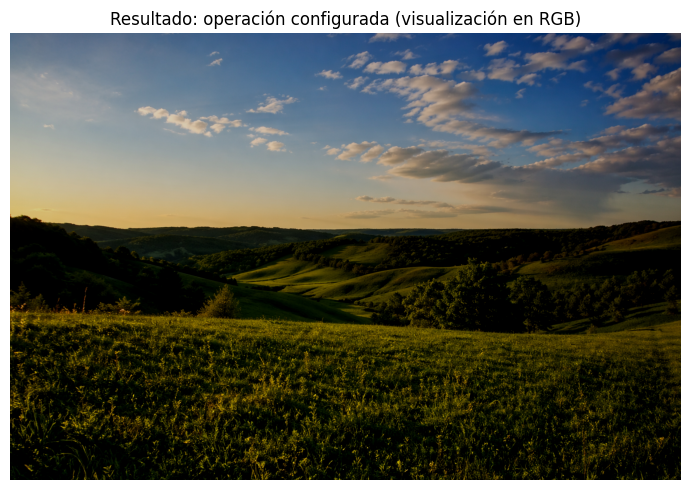

Guardado: resultado_calculadora.png


In [40]:
# Salida de la operación elegida en las secciones 4 y 5 (array uint8 BGR)
RUTA_SALIDA = 'resultado_calculadora.png'
plt.figure(figsize=(8, 5))
plt.imshow(bgr2rgb(resultado))
plt.title('Resultado: operación configurada (visualización en RGB)')
plt.axis('off')
plt.tight_layout()
plt.show()
imwrite(RUTA_SALIDA, resultado)
print('Guardado:', RUTA_SALIDA)



### Vista comparativa: aritméticas (escalar K) y puntuales

Fila 1: suma, resta y producto con el mismo K. Fila 2: cociente, raíz cuadrada e imagen de referencia. Ajusta K en la sección 4 para ver cambios de brillo/contraste.

Al ejecutar la celda siguiente se guarda además comparativa_aritmetica_puntuales.png.



Figura guardada: comparativa_aritmetica_puntuales.png


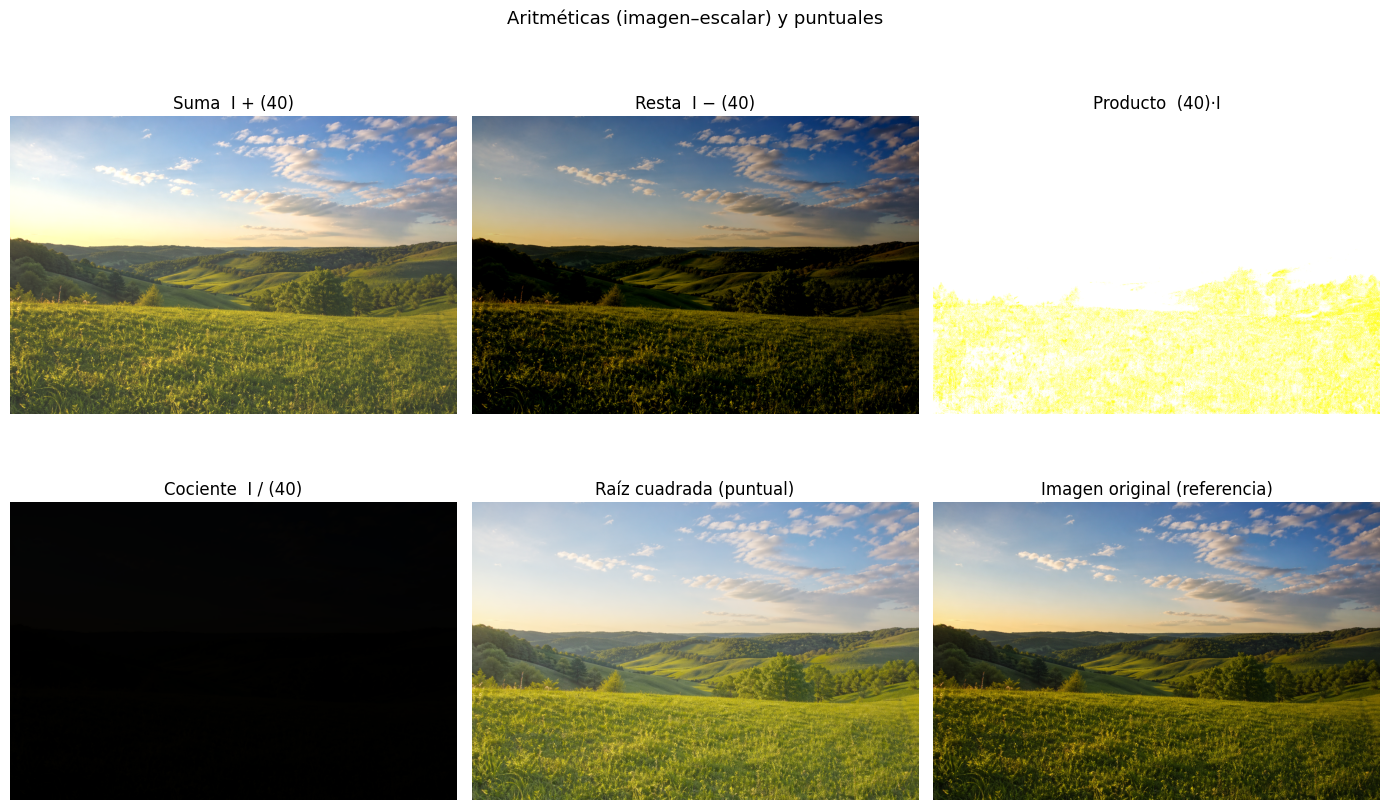

In [36]:
assert abs(float(K)) > 1e-12, 'Para la fila de comparación, elija K distinto de 0 (la división lo requiere).'

s_add = suma_escalar(img_a, K)
s_sub = resta_escalar(img_a, K)
s_mul = multiplicacion_escalar(img_a, K)
s_div = division_escalar(img_a, K)
r2 = puntual(img_a, 'raiz2')

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
L = [
    (s_add, f'Suma  I + ({K:g})'),
    (s_sub, f'Resta  I − ({K:g})'),
    (s_mul, f'Producto  ({K:g})·I'),
    (s_div, f'Cociente  I / ({K:g})'),
    (r2, 'Raíz cuadrada (puntual)'),
    (img_a, 'Imagen original (referencia)'),
]
ax = axes.ravel()
for i, (im, t) in enumerate(L):
    if im.ndim == 2:
        ax[i].imshow(im, cmap='gray')
    else:
        ax[i].imshow(bgr2rgb(im))
    ax[i].set_title(t)
    ax[i].axis('off')
plt.suptitle('Aritméticas (imagen–escalar) y puntuales', fontsize=13)
plt.tight_layout()
RUTA_COMP_ARIT = 'comparativa_aritmetica_puntuales.png'
fig.savefig(RUTA_COMP_ARIT, dpi=150, bbox_inches='tight')
print('Figura guardada:', RUTA_COMP_ARIT)
plt.show()



### Vista comparativa: geométricas

Desplazamiento y rotación con los mismos `TX`, `TY` y `ANGULO` de la sección 4.

Al ejecutar la celda siguiente se guarda **`comparativa_geometricas.png`** en la carpeta del notebook.


Figura guardada: comparativa_geometricas.png


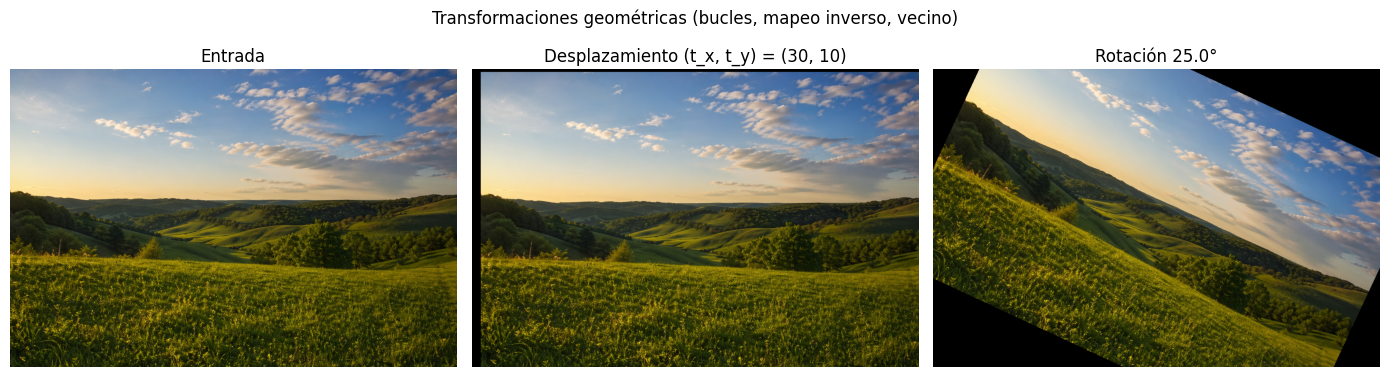

In [41]:
# Comparativa: desplazamiento y rotación (mismos TX, TY, ANGULO que en la sección 4)
RUTA_COMP_GEO = "comparativa_geometricas.png"

d0 = desplazamiento(img_a, TX, TY)
r0 = rotacion(img_a, ANGULO)
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(bgr2rgb(img_a))
ax[0].set_title("Entrada")
ax[0].axis("off")
ax[1].imshow(bgr2rgb(d0))
ax[1].set_title("Desplazamiento (t_x, t_y) = (" + str(int(TX)) + ", " + str(int(TY)) + ")")
ax[1].axis("off")
ax[2].imshow(bgr2rgb(r0))
ax[2].set_title("Rotación " + str(ANGULO) + "°")
ax[2].axis("off")
plt.suptitle("Transformaciones geométricas (bucles, mapeo inverso, vecino)", fontsize=12)
plt.tight_layout()
fig.savefig(
    RUTA_COMP_GEO,
    format="png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white",
)
print("Figura guardada:", RUTA_COMP_GEO)
plt.show()
